In [28]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

carga del dataset

In [29]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  
    transforms.Resize((48, 48)),                 
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dir = "./train"
test_dir = "./test"

trainset = datasets.ImageFolder(root=train_dir, transform=transform)
testset = datasets.ImageFolder(root=test_dir, transform=transform)

classes = trainset.classes
print("Clases:", classes)
print("Cantidad en train:", len(trainset))
print("Cantidad en test:", len(testset))




Clases: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Cantidad en train: 28709
Cantidad en test: 7178


dataloader


In [30]:
dataloader = {
    'train': DataLoader(trainset, batch_size=32, shuffle=True),
    'val': DataLoader(testset, batch_size=1000, shuffle=False)
}

In [31]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)

def build_model(D_in=48*48, H1=1000, H2=500, H3=250, D_out=7):
    return torch.nn.Sequential(
        torch.nn.Flatten(),
        torch.nn.Linear(D_in, H1),   
        torch.nn.ReLU(),
        torch.nn.Linear(H1, H2),    
        torch.nn.ReLU(),
        torch.nn.Linear(H2, H3),     
        torch.nn.ReLU(),
        torch.nn.Linear(H3, D_out)  
    )



funcion de entrenamiento

In [32]:
def fit(model, dataloader, optimizer, epochs=20, log_each=5, weight_decay=0, early_stopping=10):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0

    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(y_pred, axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))

        # evaluación en validación
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(y_pred, axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))

        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')  # solo pesos
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1

        # early stopping
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break

        if not e % log_each:
            print(f"Epoch {e}/{epochs} | loss {l[-1]:.5f} acc {acc[-1]:.5f} | val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")

    # cargar mejor modelo de forma segura
    model.load_state_dict(torch.load('ckpt.pt', weights_only=True))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}


sgd


In [ ]:

model = build_model(D_in=48*48, H1=1000, H2=500, H3=250, D_out=len(classes))
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
hist_sgd = fit(model, dataloader, optimizer)


Mejor modelo guardado con acc 0.22113 en epoch 1
Mejor modelo guardado con acc 0.22175 en epoch 2


momentun

In [ ]:
model = build_model(D_in=48*48, H1=1000, H2=500, H3=250, D_out=len(classes))
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_momentum = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.22733 en epoch 1
Mejor modelo guardado con acc 0.33085 en epoch 2
Mejor modelo guardado con acc 0.37808 en epoch 3
Mejor modelo guardado con acc 0.39365 en epoch 4
Mejor modelo guardado con acc 0.40343 en epoch 5
Epoch 5/10 | loss 1.58161 acc 0.38538 | val_loss 1.58463 val_acc 0.40343
Mejor modelo guardado con acc 0.42717 en epoch 7
Mejor modelo guardado con acc 0.43091 en epoch 9
Mejor modelo guardado con acc 0.43638 en epoch 10
Epoch 10/10 | loss 1.41806 acc 0.46377 | val_loss 1.50561 val_acc 0.43638


 RMSprop

In [ ]:
model = build_model(D_in=48*48, H1=1000, H2=500, H3=250, D_out=len(classes))
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
hist_rms = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.37916 en epoch 1
Mejor modelo guardado con acc 0.41721 en epoch 3
Mejor modelo guardado con acc 0.42640 en epoch 4
Epoch 5/10 | loss 1.31557 acc 0.48850 | val_loss 1.59393 val_acc 0.39953
Mejor modelo guardado con acc 0.44497 en epoch 6
Mejor modelo guardado con acc 0.45396 en epoch 8
Epoch 10/10 | loss 0.92430 acc 0.64585 | val_loss 1.84226 val_acc 0.45117


ADAM

In [ ]:
model = build_model(D_in=48*48, H1=1000, H2=500, H3=250, D_out=len(classes))
soptimizer = torch.optim.Adam(model.parameters(), lr=0.001)
hist_adam = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.20700 en epoch 1
Epoch 5/10 | loss 1.94963 acc 0.11035 | val_loss 1.94009 val_acc 0.20700
Epoch 10/10 | loss 1.94962 acc 0.11035 | val_loss 1.94009 val_acc 0.20700


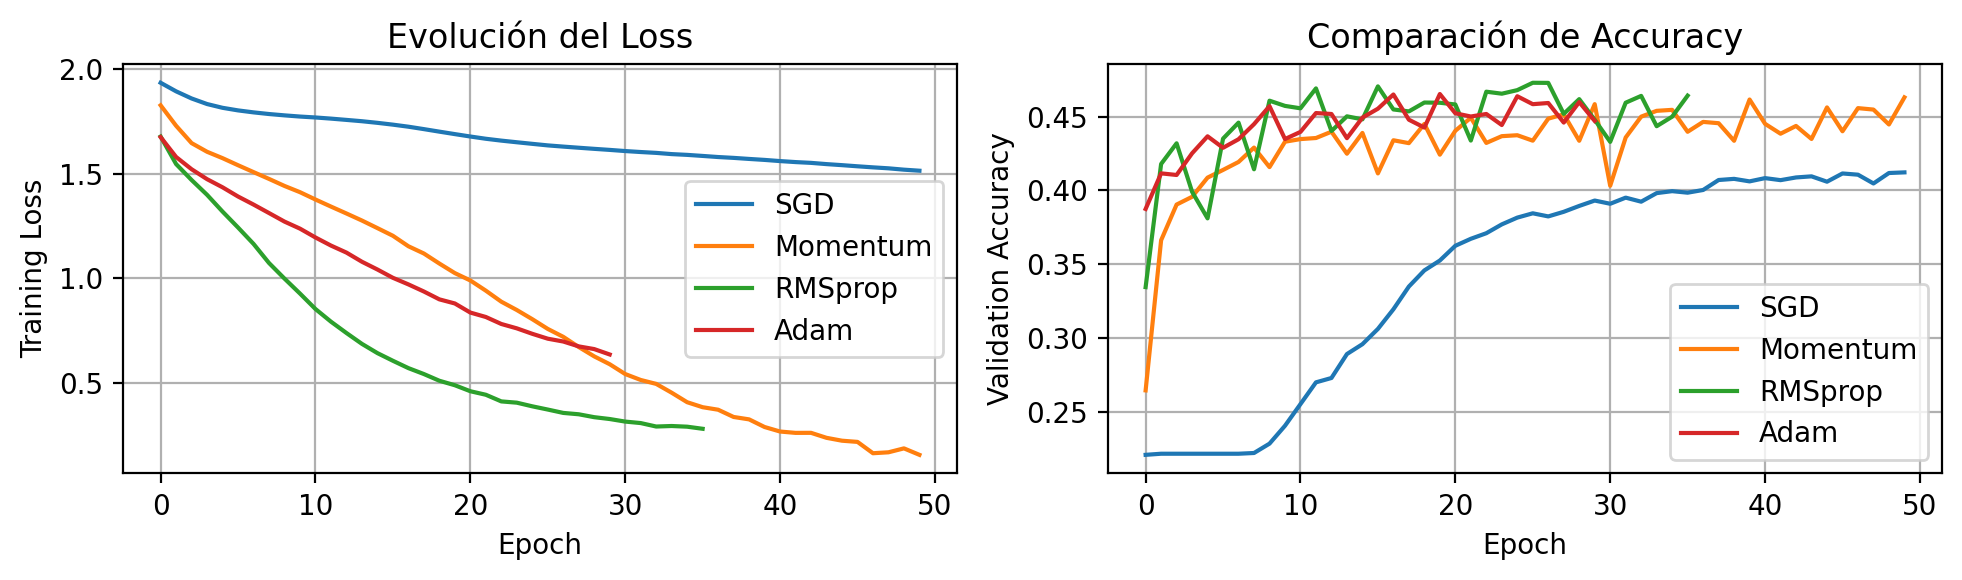

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(dpi=200, figsize=(10,3))

# Curvas de pérdida (loss)
ax = plt.subplot(121)
ax.plot(hist_sgd['loss'], label="SGD")
ax.plot(hist_momentum['loss'], label="Momentum")
ax.plot(hist_rms['loss'], label="RMSprop")
ax.plot(hist_adam['loss'], label="Adam")
ax.legend()
ax.grid(True)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title("Evolución del Loss")

# Curvas de accuracy en validación
ax = plt.subplot(122)
ax.plot(hist_sgd['val_acc'], label="SGD")
ax.plot(hist_momentum['val_acc'], label="Momentum")
ax.plot(hist_rms['val_acc'], label="RMSprop")
ax.plot(hist_adam['val_acc'], label="Adam")
ax.legend()
ax.grid(True)
ax.set_ylabel('Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_title("Comparación de Accuracy")

plt.tight_layout()
plt.show()
